# 车辆轨迹提取：无高斯模板增强（直接峰检测）

这个 Notebook 演示一个对照流程：**不做高斯模板增强**，直接在 `|signal|` 上做峰检测，然后进入后续步骤。

In [2]:
from __future__ import annotations

import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

from auto_track_backend import AutoTrackBackend, DEFAULT_DATA_FOLDER
from track_extractor_graph import (
    ExtractorConfig,
    _extract_best_track,
    _suppress_nodes,
)

plt.rcParams["figure.figsize"] = (13, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


## 0) 参数设置

In [3]:
DATA_FOLDER = DEFAULT_DATA_FOLDER
WINDOW_START_S = 1200.0
WINDOW_SECONDS = 120.0

DIRECTION = "forward"
SPEED_MIN_KMH = 60.0
SPEED_MAX_KMH = 120.0

CFG = ExtractorConfig(
    sigma_seconds=(0.06, 0.10, 0.14, 0.18),
    enhance_decimate=2,
    prominence=0.4,
    min_peak_distance=500,
    min_track_channels=12,
    nms_time_radius=180,
)

MAX_TRACKS_DEMO = 30

print("DATA_FOLDER:", DATA_FOLDER)
print("WINDOW:", WINDOW_START_S, "->", WINDOW_START_S + WINDOW_SECONDS, "s")
print("SPEED:", SPEED_MIN_KMH, "~", SPEED_MAX_KMH, "km/h")
print("CONFIG:", CFG)


DATA_FOLDER: /Volumes/SanDisk2T4/MyProjects/BaFang/KF/data/synthetic_sac
WINDOW: 1200.0 -> 1320.0 s
SPEED: 60.0 ~ 120.0 km/h
CONFIG: ExtractorConfig(sigma_seconds=(0.06, 0.1, 0.14, 0.18), use_template_enhancement=True, enhance_decimate=2, prominence=0.4, min_peak_distance=500, max_skip_channels=4, lambda_speed=2.0, lambda_skip=0.55, speed_change_tolerance_kmh=18.0, speed_penalty_power=0.85, speed_penalty_cap=2.5, min_track_channels=12, min_track_score=10.0, edge_relax_enabled=True, edge_min_track_channels=6, edge_time_margin_seconds=15.0, edge_min_score_scale=0.55, nms_time_radius=180, nms_channel_radius=1, max_tracks=256, max_peaks_per_channel=400)


In [4]:
def _robust_global_scale(data_plot: np.ndarray) -> float:
    eps = 1e-12
    abs_vals = np.abs(data_plot[np.isfinite(data_plot)])
    if abs_vals.size == 0:
        return 1.0
    q995 = float(np.quantile(abs_vals, 0.995))
    rms = float(np.sqrt(np.mean(abs_vals * abs_vals)))
    return max(q995, 3.0 * rms, eps)


def plot_section_wiggle(
    ax,
    data: np.ndarray,
    t_abs: np.ndarray,
    offsets_m: np.ndarray,
    target_points_per_trace: int = 3500,
    color: str = "0.45",
    lw: float = 0.75,
    alpha: float = 0.9,
):
    n_ch, n_samples = data.shape
    decim = int(max(1, np.ceil(n_samples / float(target_points_per_trace))))
    t = t_abs[::decim]
    data_plot = np.asarray(data[:, ::decim], dtype=np.float64)
    offsets_km = np.asarray(offsets_m, dtype=np.float64) * 1e-3

    if offsets_km.size >= 2:
        spacing = float(np.median(np.diff(offsets_km)))
        if (not np.isfinite(spacing)) or spacing <= 0:
            spacing = 0.1
    else:
        spacing = 0.

    wiggle_amp = 0.27 * spacing
    clip_ratio = 1.35
    global_ref = _robust_global_scale(data_plot)

    for i in range(n_ch):
        ratio = np.clip(data_plot[i] / global_ref, -clip_ratio, clip_ratio)
        x = offsets_km[i] + ratio * wiggle_amp
        ax.plot(x, t, color=color, linewidth=lw, alpha=alpha)

    pad = 0.4 * spacing
    ax.set_xlim(offsets_km.min() - pad, offsets_km.max() + pad)
    ax.set_ylim(float(np.max(t_abs)), float(np.min(t_abs)))
    ax.set_xlabel("Path / Offset [km]")
    ax.set_ylabel("Time [s]")


def overlay_tracks(
    ax,
    tracks,
    time_offset_s: float = 0.0,
    cmap_name: str = "tab20",
    lw: float = 1.4,
    s: float = 12.0,
    alpha_line: float = 0.95,
):
    cmap = plt.get_cmap(cmap_name, max(1, len(tracks)))
    for i, tr in enumerate(tracks):
        if len(tr.points) < 2:
            continue
        pts = sorted(tr.points, key=lambda p: p.ch_idx)
        xs = np.array([p.offset_m * 1e-3 for p in pts], dtype=np.float64)
        ys = np.array([p.time_s + time_offset_s for p in pts], dtype=np.float64)
        color = cmap(i % max(1, cmap.N))
        ax.plot(xs, ys, color=color, linewidth=lw, alpha=alpha_line)
        ax.scatter(xs, ys, color=[color], s=s, alpha=0.9)

        if np.isfinite(float(tr.mean_speed_kmh)):
            mid = len(xs) // 2
            ax.text(
                xs[mid],
                ys[mid],
                f"{float(tr.mean_speed_kmh):.1f} km/h",
                color=color,
                fontsize=8,
                ha="left",
                va="center",
                bbox={"facecolor": "white", "alpha": 0.55, "edgecolor": "none", "pad": 0.6},
            )


def build_nodes_no_template(data: np.ndarray, fs: float, cfg: ExtractorConfig):
    # 不做高斯模板增强：直接用 abs(signal) 构建候选峰节点
    abs_data = np.abs(data).astype(np.float32, copy=False)
    decim = int(max(1, cfg.enhance_decimate))

    if decim > 1:
        abs_work = abs_data[:, ::decim]
        peak_distance = int(max(1, round(float(cfg.min_peak_distance) / float(decim))))
    else:
        abs_work = abs_data
        peak_distance = int(max(1, cfg.min_peak_distance))

    channel_nodes = []
    for ch in range(data.shape[0]):
        peaks, props = find_peaks(
            abs_work[ch],
            prominence=cfg.prominence,
            distance=peak_distance,
        )
        if peaks.size == 0:
            channel_nodes.append(
                {
                    "t": np.empty((0,), dtype=np.int32),
                    "amp": np.empty((0,), dtype=np.float32),
                    "score": np.empty((0,), dtype=np.float32),
                }
            )
            continue

        if decim > 1:
            peaks = np.minimum(
                peaks.astype(np.int64, copy=False) * int(decim),
                int(data.shape[1] - 1),
            ).astype(np.int32, copy=False)

        prominences = props.get("prominences", np.zeros(peaks.shape[0], dtype=np.float32)).astype(np.float32)
        amps = abs_data[ch, peaks].astype(np.float32, copy=False)
        amp_ref = float(np.median(amps) + 1e-6)
        amp_norm = amps / amp_ref
        node_score = prominences + 0.2 * amp_norm

        if peaks.size > cfg.max_peaks_per_channel:
            idx_top = np.argsort(node_score)[-cfg.max_peaks_per_channel :]
            peaks = peaks[idx_top]
            amps = amps[idx_top]
            node_score = node_score[idx_top]

        order = np.argsort(peaks)
        channel_nodes.append(
            {
                "t": peaks[order].astype(np.int32, copy=False),
                "amp": amps[order].astype(np.float32, copy=False),
                "score": node_score[order].astype(np.float32, copy=False),
            }
        )

    return channel_nodes, abs_data


## 1) 加载数据 + 原始 section

data shape=(50, 120000), fs=1000.000Hz, dx=100.00m
window=[1200.0, 1320.0] s


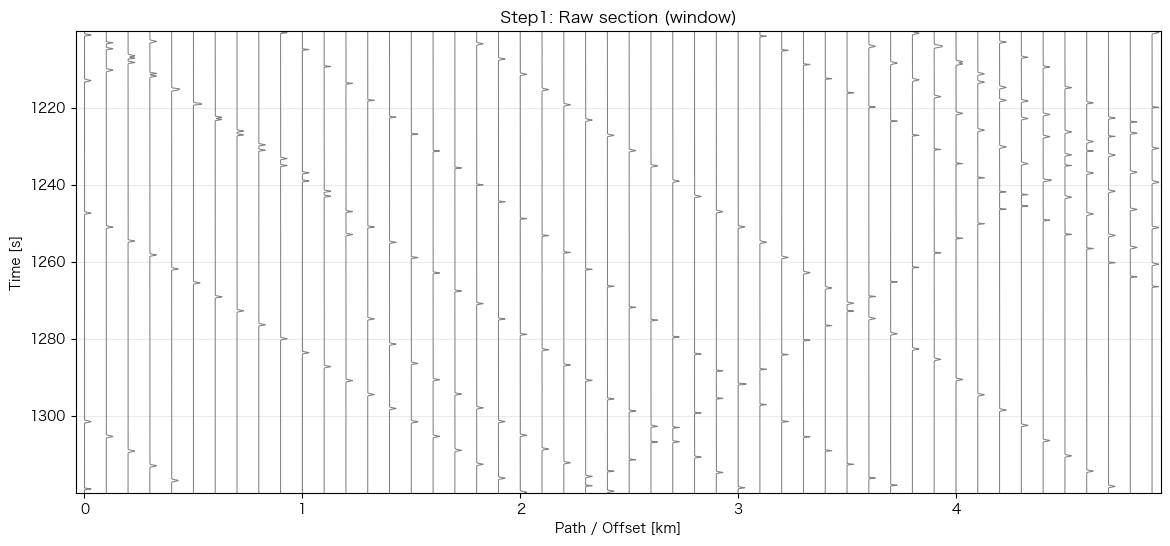

In [5]:
backend = AutoTrackBackend(data_folder=DATA_FOLDER)
if backend.init_error:
    raise RuntimeError(backend.init_error)

backend.window_size = int(round(WINDOW_SECONDS * backend.fs))
backend.current_start = int(round(WINDOW_START_S * backend.fs))
backend.update_view_window()

data = backend.data_view
fs = float(backend.fs)
dx_m = float(backend.dx_m)
window_t0 = float(backend.current_start) / fs
window_t1 = float(backend.current_start + backend.window_size) / fs
t_abs = np.arange(data.shape[1], dtype=np.float64) / fs + window_t0
offsets_m = backend.x_axis_m.copy()

print(f"data shape={data.shape}, fs={fs:.3f}Hz, dx={dx_m:.2f}m")
print(f"window=[{window_t0:.1f}, {window_t1:.1f}] s")

fig, ax = plt.subplots(figsize=(14, 6))
plot_section_wiggle(ax, data, t_abs, offsets_m)
ax.set_title("Step1: Raw section (window)")
plt.show()


## 2) 检测底图（不增强，直接使用 |signal|）

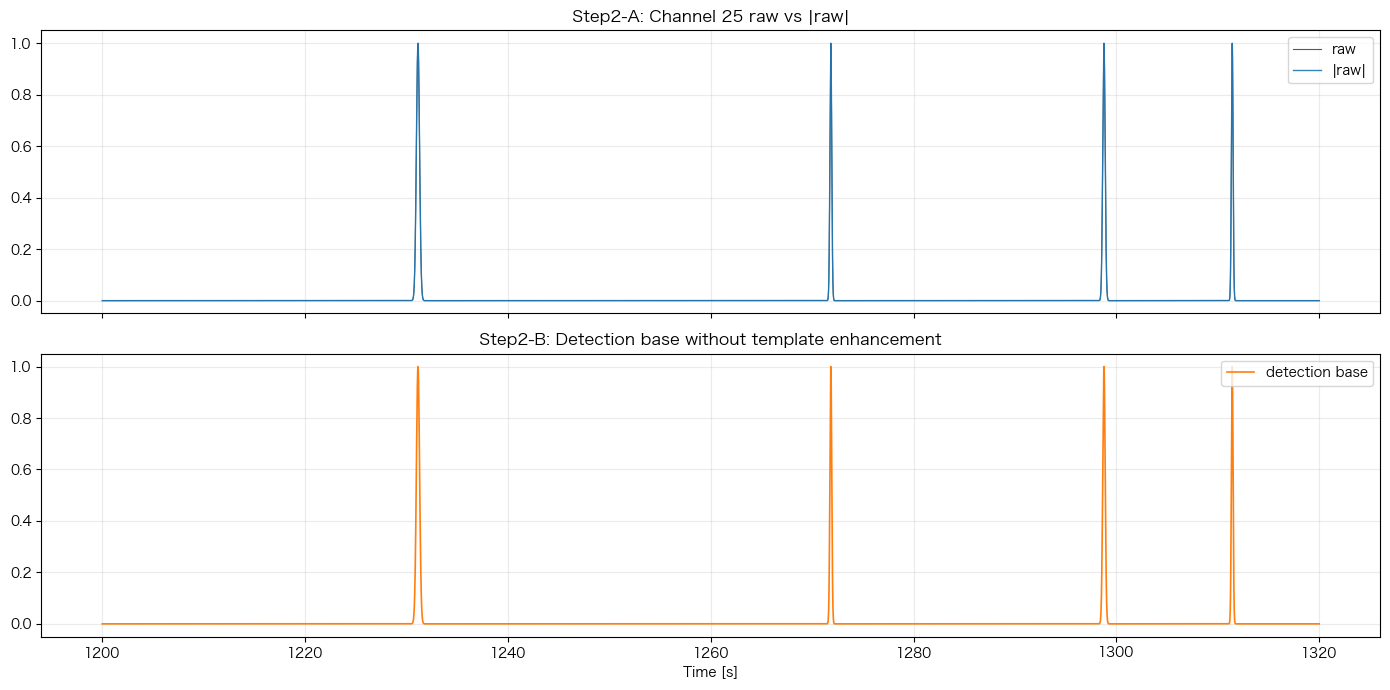

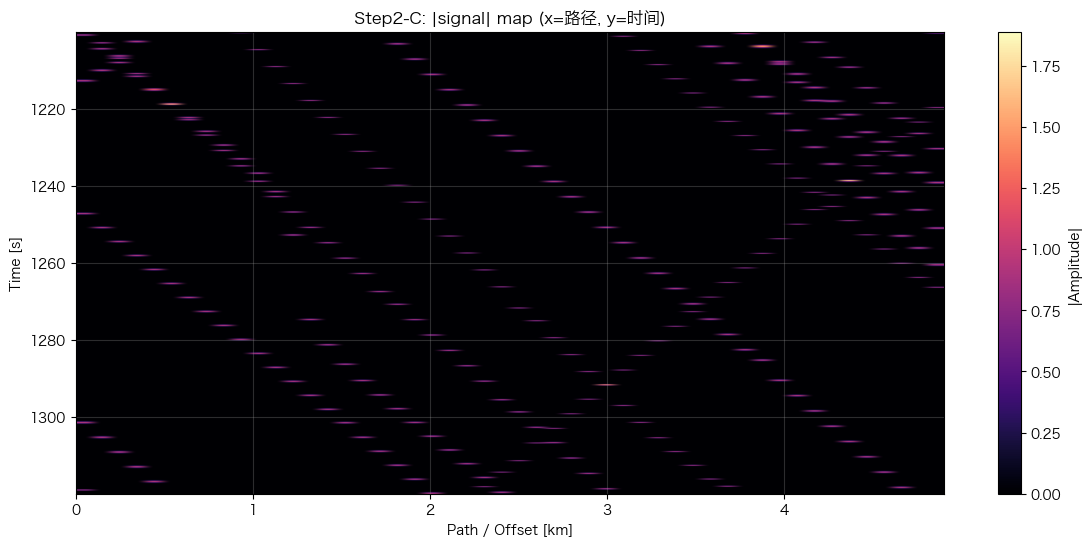

In [6]:
nodes_no_tmpl, abs_data = build_nodes_no_template(data, fs=fs, cfg=CFG)

ch_demo = int(data.shape[0] // 2)
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(t_abs, data[ch_demo], color="0.35", lw=0.8, label="raw")
axes[0].plot(t_abs, abs_data[ch_demo], color="tab:blue", lw=1.0, alpha=0.9, label="|raw|")
axes[0].set_title(f"Step2-A: Channel {ch_demo} raw vs |raw|")
axes[0].legend(loc="upper right")

axes[1].plot(t_abs, abs_data[ch_demo], color="tab:orange", lw=1.2, label="detection base")
axes[1].set_title("Step2-B: Detection base without template enhancement")
axes[1].set_xlabel("Time [s]")
axes[1].legend(loc="upper right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(
    abs_data.T,
    aspect="auto",
    origin="lower",
    extent=[offsets_m[0] * 1e-3, offsets_m[-1] * 1e-3, t_abs[0], t_abs[-1]],
    cmap="magma",
)
ax.set_title("Step2-C: |signal| map (x=路径, y=时间)")
ax.set_xlabel("Path / Offset [km]")
ax.set_ylabel("Time [s]")
ax.set_ylim(t_abs[-1], t_abs[0])
fig.colorbar(im, ax=ax, label="|Amplitude|")
plt.show()


## 3) 候选峰检测（直接在 |signal| 上）

candidate count: 232
mean candidates/channel: 4.64


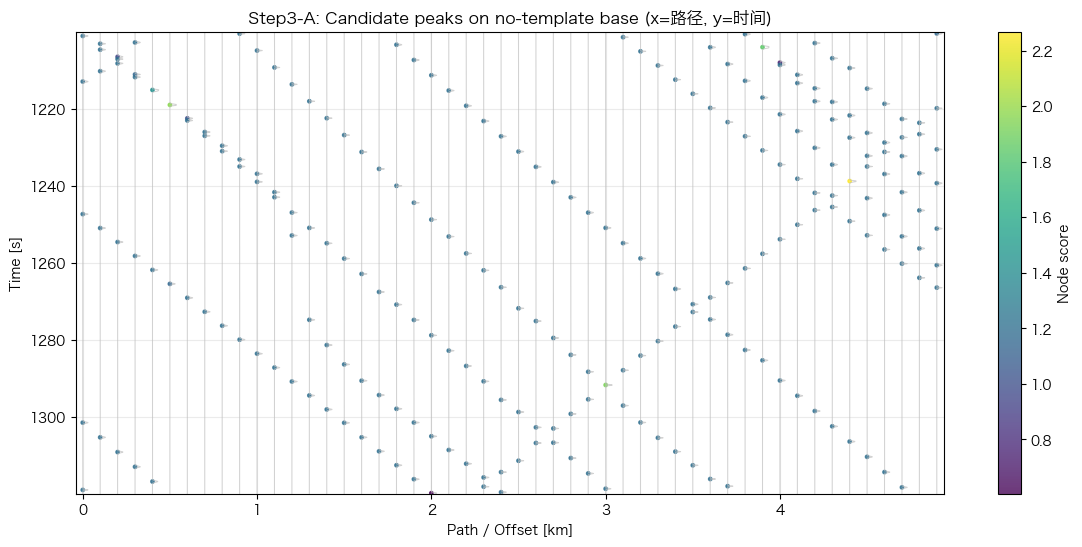

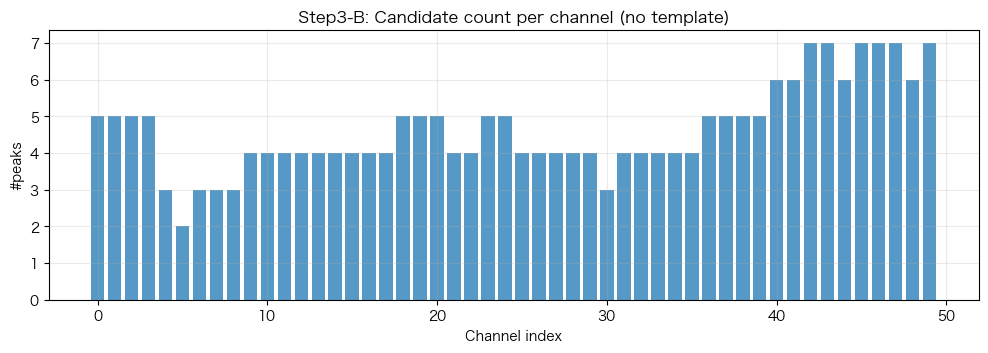

In [7]:
all_x      = []
all_y_time = []
all_s      = []
for ch, nd in enumerate(nodes_no_tmpl):
    if nd["t"].size == 0:
        continue
    all_x.append(np.full(nd["t"].shape, offsets_m[ch] * 1e-3, dtype=np.float64))
    all_y_time.append(nd["t"] / fs + window_t0)
    all_s.append(nd["score"].astype(np.float64))

if all_x:
    cand_x = np.concatenate(all_x)
    cand_y_time = np.concatenate(all_y_time)
    cand_s = np.concatenate(all_s)
else:
    cand_x = np.empty((0,), dtype=np.float64)
    cand_y_time = np.empty((0,), dtype=np.float64)
    cand_s = np.empty((0,), dtype=np.float64)

print("candidate count:", cand_x.size)
print("mean candidates/channel:", cand_x.size / max(1, data.shape[0]))

fig, ax = plt.subplots(figsize=(14, 6))
plot_section_wiggle(ax, data, t_abs, offsets_m, color="0.75", alpha=0.7)
if cand_x.size:
    sc = ax.scatter(cand_x, cand_y_time, c=cand_s, s=6, cmap="viridis", alpha=0.78)
    fig.colorbar(sc, ax=ax, label="Node score")
ax.set_title("Step3-A: Candidate peaks on no-template base (x=路径, y=时间)")
plt.show()

per_ch = np.array([len(n["t"]) for n in nodes_no_tmpl], dtype=np.int32)
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(np.arange(per_ch.size), per_ch, color="tab:blue", alpha=0.75)
ax.set_title("Step3-B: Candidate count per channel (no template)")
ax.set_xlabel("Channel index")
ax.set_ylabel("#peaks")
plt.show()


## 4) 速度窗约束可视化

seed channel=25, next channel=26, dx=100.0m
seed time=1231.130s, allowed next time=[1234.130, 1237.130]s
candidates on ch26: total=4, valid=1


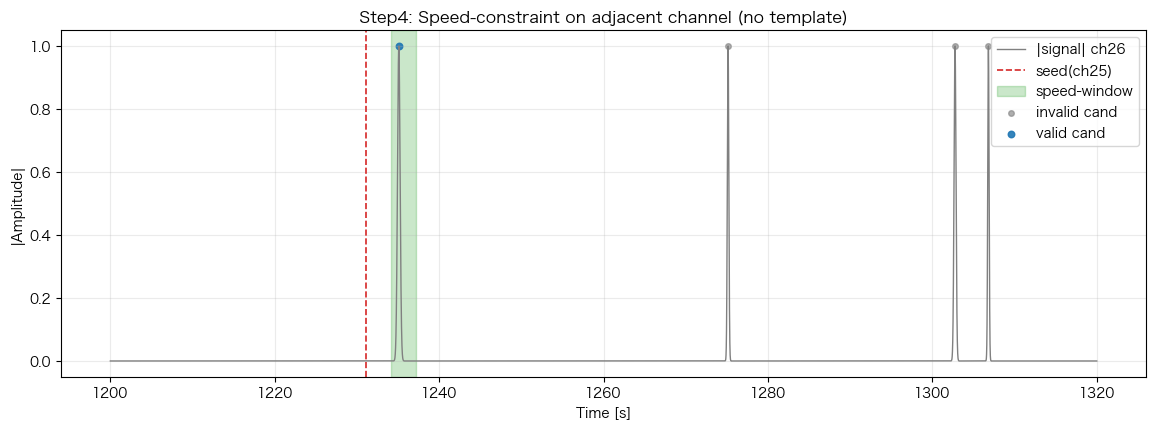

In [8]:
ch0 = int(data.shape[0] // 2)
ch1 = min(data.shape[0] - 1, ch0 + 1)
if nodes_no_tmpl[ch0]["t"].size == 0 or nodes_no_tmpl[ch1]["t"].size == 0:
    raise RuntimeError("演示通道没有候选峰，请调整窗口或阈值。")

seed_idx = int(np.argmax(nodes_no_tmpl[ch0]["score"]))
seed_idx = 0
seed_t_local = float(nodes_no_tmpl[ch0]["t"][seed_idx]) / fs
seed_t_abs = seed_t_local + window_t0

dx = abs(float(offsets_m[ch1] - offsets_m[ch0]))
vmin_mps = SPEED_MIN_KMH / 3.6
vmax_mps = SPEED_MAX_KMH / 3.6
if DIRECTION == "forward":
    dt_lo = dx / vmax_mps
    dt_hi = dx / vmin_mps
else:
    dt_lo = -dx / vmin_mps
    dt_hi = -dx / vmax_mps

pred_lo = seed_t_abs + min(dt_lo, dt_hi)
pred_hi = seed_t_abs + max(dt_lo, dt_hi)

cand1_abs = nodes_no_tmpl[ch1]["t"] / fs + window_t0
valid = (cand1_abs >= pred_lo) & (cand1_abs <= pred_hi)

print(f"seed channel={ch0}, next channel={ch1}, dx={dx:.1f}m")
print(f"seed time={seed_t_abs:.3f}s, allowed next time=[{pred_lo:.3f}, {pred_hi:.3f}]s")
print(f"candidates on ch{ch1}: total={cand1_abs.size}, valid={int(np.sum(valid))}")

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(t_abs, abs_data[ch1], color="0.5", lw=1.0, label=f"|signal| ch{ch1}")
ax.axvline(seed_t_abs, color="tab:red", lw=1.2, ls="--", label=f"seed(ch{ch0})")
ax.axvspan(pred_lo, pred_hi, color="tab:green", alpha=0.25, label="speed-window")
ax.scatter(cand1_abs[~valid], abs_data[ch1, nodes_no_tmpl[ch1]["t"][~valid]], s=16, color="0.55", alpha=0.7, label="invalid cand")
ax.scatter(cand1_abs[valid], abs_data[ch1, nodes_no_tmpl[ch1]["t"][valid]], s=22, color="tab:blue", alpha=0.9, label="valid cand")
ax.set_title("Step4: Speed-constraint on adjacent channel (no template)")
ax.set_xlabel("Time [s]")
ax.set_ylabel("|Amplitude|")
ax.legend(loc="upper right")
plt.show()


## 5) 单条最优轨迹（DP）

这一节的目标不是“把所有候选峰都连起来”，而是：

**在所有候选峰节点里，找一条从前到后累计得分最高、同时满足速度约束的路径。**

你可以把它理解成一个“带约束的图搜索问题”：

- 每个通道上的每个候选峰，都是一个节点 `(ch, j)`
- 节点自带一个局部分数 `node_score`
- 只有时间差落在速度窗内的两个节点，才允许连边
- 如果跨了多个通道才连上，会有 `skip_penalty`
- 如果当前边的速度和前面轨迹的速度不一致太多，会有 `speed_penalty`

### 5.1 DP 里到底存了什么？

对当前通道 `ch` 上的第 `j` 个候选峰，算法维护：

- `dp_score[ch][j]`：**以这个节点结尾**时，当前能得到的最佳累计分数
- `dp_len[ch][j]`：这条最佳路径包含多少个节点
- `dp_prev_ch[ch][j]`, `dp_prev_idx[ch][j]`：这个最佳结果是从哪个前驱节点转移来的
- `dp_speed[ch][j]`：这条路径当前的“平滑速度估计”
- `dp_tmin[ch][j]`, `dp_tmax[ch][j]`：这条路径覆盖到的最早/最晚时间，用于后面的边缘放宽判定

初始化时，每个候选峰都可以单独成一条长度为 1 的轨迹，所以初始值就是：

- `dp_score = node_score`
- `dp_len = 1`
- `prev = -1`

prev_dp
前驱点那条路径到目前为止已经攒下来的总分，每个点只保留“到达这个点的最佳历史”，不保留所有历史。
意义：历史越好，这条路越有优势

curr_score
当前点自己的 node_score
意义：当前点本身越像真峰，越加分

speed_penalty
速度变化太大时扣分
意义：鼓励轨迹速度平滑，别一会儿快一会儿慢

skip_penalty
如果不是从 ch-1 连过来，而是跳过了中间通道，比如 ch-2 -> ch
就扣分
意义：鼓励轨迹连续，不要老跨道跳连

所以 DP 真正在做的是：

“历史好 + 当前点好 - 不合理连接的惩罚”


### 5.2 转移公式是什么？

如果当前节点是 `(ch, j)`，算法会往前看 `1 ~ max_skip_channels` 个通道。对每个可能前驱 `(pch, i)`，先判断它们的时间差 `dt` 是否满足速度约束：

```python
candidate_total = prev_dp_score + curr_node_score - speed_penalty - skip_penalty
```

其中：

- `prev_dp_score`：前驱节点那条路径已经累计好的分数
- `curr_node_score`：当前节点自己的局部分数
- `skip_penalty`：如果跳过了中间通道，就扣分
- `speed_penalty`：如果这一段速度和已有轨迹速度变化太大，就扣分

如果多个前驱都合法，就选 `candidate_total` 最大的那个；如果分数几乎一样，就优先选更长的路径。

### 5.3 这一节你应该盯着看什么？

下面的图我会分成 4 层来解释：

1. 候选峰的**局部分数**是什么样子
2. 经过 DP 累积以后，哪些节点变成了“更值得作为轨迹终点”的节点
3. 对某一个中间节点，DP 是怎么在多个前驱里选出最优前驱的
4. 最后如何从最佳终点一路回溯出整条轨迹


In [ ]:
def _dp_dt_bounds(direction: str, delta_x_m: float, vmin_mps: float, vmax_mps: float):
    if direction == "forward":
        return delta_x_m / vmax_mps, delta_x_m / vmin_mps
    if direction == "reverse":
        return -delta_x_m / vmin_mps, -delta_x_m / vmax_mps
    raise ValueError("direction must be either forward or reverse")


def run_dp_debug(nodes, fs, dx_m, direction, vmin_mps, vmax_mps, n_samples, config):
    """教学版 DP：完全复现主算法的状态更新，但额外把中间状态保留下来用于画图。"""
    n_ch        = len(nodes)
    dp_score    = []
    dp_len      = []
    dp_speed    = []
    dp_tmin     = []
    dp_tmax     = []
    dp_prev_ch  = []
    dp_prev_idx = []

    speed_scale   = max(1e-6, float(vmax_mps - vmin_mps))
    speed_tol_mps = max(0.0, float(config.speed_change_tolerance_kmh) / 3.6)
    speed_pow     = float(max(0.5, config.speed_penalty_power))
    speed_pen_cap = float(max(0.0, config.speed_penalty_cap))

    for ch in range(n_ch):
        t_curr = nodes[ch]["t"]
        s_curr = nodes[ch]["score"]
        n_curr = t_curr.size
        if n_curr == 0:
            dp_score.append(np.empty((0,), dtype=np.float32))
            dp_len.append(np.empty((0,), dtype=np.int32))
            dp_speed.append(np.empty((0,), dtype=np.float32))
            dp_tmin.append(np.empty((0,), dtype=np.int32))
            dp_tmax.append(np.empty((0,), dtype=np.int32))
            dp_prev_ch.append(np.empty((0,), dtype=np.int16))
            dp_prev_idx.append(np.empty((0,), dtype=np.int32))
            continue

        score_arr    = s_curr.astype(np.float32, copy=True)
        len_arr      = np.ones((n_curr,), dtype=np.int32)
        speed_arr    = np.full((n_curr,), np.nan, dtype=np.float32)
        tmin_arr     = t_curr.astype(np.int32, copy=True)
        tmax_arr     = t_curr.astype(np.int32, copy=True)
        prev_ch_arr  = np.full((n_curr,), -1, dtype=np.int16)
        prev_idx_arr = np.full((n_curr,), -1, dtype=np.int32)

        # 遍历 skip channels，主要是前一道
        for dch in range(1, config.max_skip_channels + 1):
            pch = ch - dch
            if pch < 0:
                continue
            t_prev = nodes[pch]["t"]
            if t_prev.size == 0:
                continue

            prev_score = dp_score[pch]
            prev_len   = dp_len[pch]
            prev_speed = dp_speed[pch]
            prev_tmin  = dp_tmin[pch]
            prev_tmax  = dp_tmax[pch]
            delta_x    = float(dch * dx_m)
            dt_low, dt_high = _dp_dt_bounds(direction, delta_x, vmin_mps, vmax_mps)
            skip_penalty = float(config.lambda_skip * max(0, dch - 1))

            for j in range(n_curr):
                dt = (float(t_curr[j]) - t_prev.astype(np.float64)) / float(fs)
                valid = (dt >= dt_low) & (dt <= dt_high)
                if not np.any(valid):
                    continue

                idx            = np.where(valid)[0]
                dt_sel         = dt[idx]
                speed_sel      = delta_x / np.maximum(np.abs(dt_sel), 1e-9)
                prev_speed_sel = prev_speed[idx].astype(np.float64)
                prev_speed_sel = np.where(np.isfinite(prev_speed_sel), prev_speed_sel, speed_sel)
                speed_delta    = np.abs(speed_sel - prev_speed_sel)
                speed_excess   = np.maximum(0.0, speed_delta - speed_tol_mps)
                speed_pen      = config.lambda_speed * np.power(speed_excess / speed_scale, speed_pow)
                if speed_pen_cap > 0:
                    speed_pen = np.minimum(speed_pen, speed_pen_cap)    # 速度控制，不能和之前发生太大的变化

                cand = prev_score[idx].astype(np.float64) + float(s_curr[j]) - speed_pen - skip_penalty
                tie = cand + 1e-4 * prev_len[idx].astype(np.float64)
                k = int(np.argmax(tie))
                cand_score = float(cand[k])
                cand_len = int(prev_len[idx[k]]) + 1

                if cand_score > float(score_arr[j]) + 1e-12 or (
                    abs(cand_score - float(score_arr[j])) <= 1e-12 and cand_len > int(len_arr[j])
                ):
                    prev_idx = int(idx[k])
                    score_arr[j] = np.float32(cand_score)
                    len_arr[j] = np.int32(cand_len)
                    prev_ch_arr[j] = np.int16(pch)
                    prev_idx_arr[j] = np.int32(prev_idx)
                    speed_arr[j] = np.float32(0.7 * prev_speed_sel[k] + 0.3 * speed_sel[k])
                    tmin_arr[j] = np.int32(min(int(prev_tmin[prev_idx]), int(t_curr[j])))
                    tmax_arr[j] = np.int32(max(int(prev_tmax[prev_idx]), int(t_curr[j])))

        dp_score.append(score_arr)          # score_arr：当前道所有候选点的得分（最高得分））
        dp_len.append(len_arr)
        dp_speed.append(speed_arr)
        dp_tmin.append(tmin_arr)
        dp_tmax.append(tmax_arr)
        dp_prev_ch.append(prev_ch_arr)      # 往前的候选点的道数
        dp_prev_idx.append(prev_idx_arr)    # 往前的候选点的点数

    # 对窗口边界附近的轨迹放宽要求。
    # 原因是：如果一条真实轨迹刚好从窗口外进入、或者在窗口内还没走完就结束，
    # 它在当前窗口里看起来会比较短、累计分也可能偏低，若仍按严格阈值筛选，容易被误删。
    edge_margin_samples = int(max(0, round(float(config.edge_time_margin_seconds) * float(fs))))
    edge_margin_samples = int(min(max(0, n_samples - 1), edge_margin_samples))
    relaxed_len = int(max(2, min(config.min_track_channels, config.edge_min_track_channels)))
    relaxed_score = float(config.min_track_score * max(0.0, float(config.edge_min_score_scale)))

    # 在所有“以某个节点为终点的局部最优路径”里，选出一个全局最佳终点。
    # 注意：dp_score[ch][j] 不是全局最好，而是“以 (ch, j) 结尾时的最佳累计分数”。
    best = None
    best_value = -np.inf
    for ch in range(n_ch):
        if dp_score[ch].size == 0:
            continue

        # 严格条件：路径长度和累计分都达到正常阈值。
        strict_valid = (dp_len[ch] >= config.min_track_channels) & (dp_score[ch] >= config.min_track_score)

        if config.edge_relax_enabled and relaxed_len < config.min_track_channels:
            # 如果开启边界放宽，则允许“碰到窗口开头或结尾”的路径用更宽松的阈值通过。
            near_start = dp_tmin[ch] <= edge_margin_samples
            near_end = dp_tmax[ch] >= (n_samples - 1 - edge_margin_samples)
            edge_touch = near_start | near_end

            # 放宽条件只对边界轨迹生效：
            # 轨迹长度可以更短，累计分可以更低，但必须确实触碰窗口边界。
            relaxed_valid = edge_touch & (dp_len[ch] >= relaxed_len) & (dp_score[ch] >= relaxed_score)
            valid = strict_valid | relaxed_valid
        else:
            valid = strict_valid

        if not np.any(valid):
            continue

        idxs = np.where(valid)[0]

        # 在当前这一道的所有合法终点里，挑分数最高的那个。
        # 如果分数几乎一样，则用一个很小的长度项做 tie-break，优先更长的路径。
        # TAG: 主要是这里
        values = dp_score[ch][idxs].astype(np.float64) + 1e-3 * dp_len[ch][idxs].astype(np.float64)
        k = int(np.argmax(values))
        val = float(values[k])

        # 再和前面各道找到的最佳终点比较，保留全局最优终点。
        if val > best_value:
            best_value = val
            best = (ch, int(idxs[k]))

    if best is None:
        return None

    # 从全局最佳终点开始，沿着 prev 指针一路往前回溯，
    # 恢复出整条轨迹的节点链。
    path = []
    ch, idx = best
    while ch >= 0 and idx >= 0:
        path.append((ch, idx))
        next_ch = int(dp_prev_ch[ch][idx]) if dp_prev_ch[ch].size > 0 else -1
        next_idx = int(dp_prev_idx[ch][idx]) if dp_prev_idx[ch].size > 0 else -1
        ch, idx = next_ch, next_idx

    # 回溯得到的顺序是“终点 -> 起点”，所以最后反转成正常时间顺序。
    path.reverse()


    return {
        "dp_score"   : dp_score,
        "dp_len"     : dp_len,
        "dp_speed"   : dp_speed,
        "dp_tmin"    : dp_tmin,
        "dp_tmax"    : dp_tmax,
        "dp_prev_ch" : dp_prev_ch,
        "dp_prev_idx": dp_prev_idx,
        "best_end"   : best,
        "best_value" : best_value,
        "path"       : path,
    }


def inspect_transition(nodes, debug, ch, j, fs, dx_m, direction, vmin_mps, vmax_mps, config):
    """展开某个当前节点的所有合法前驱，方便看 DP 为什么选中某条边。"""
    t_curr = int(nodes[ch]["t"][j])
    s_curr = float(nodes[ch]["score"][j])
    chosen_prev = (
        int(debug["dp_prev_ch"][ch][j]) if debug["dp_prev_ch"][ch].size else -1,
        int(debug["dp_prev_idx"][ch][j]) if debug["dp_prev_idx"][ch].size else -1,
    )

    speed_scale = max(1e-6, float(vmax_mps - vmin_mps))
    speed_tol_mps = max(0.0, float(config.speed_change_tolerance_kmh) / 3.6)
    speed_pow = float(max(0.5, config.speed_penalty_power))
    speed_pen_cap = float(max(0.0, config.speed_penalty_cap))

    records = []
    for dch in range(1, config.max_skip_channels + 1):
        pch = ch - dch
        if pch < 0:
            continue

        t_prev = nodes[pch]["t"]
        if t_prev.size == 0:
            continue

        delta_x = float(dch * dx_m)
        dt_low, dt_high = _dp_dt_bounds(direction, delta_x, vmin_mps, vmax_mps)
        dt = (float(t_curr) - t_prev.astype(np.float64)) / float(fs)
        valid = (dt >= dt_low) & (dt <= dt_high)
        if not np.any(valid):
            continue

        for prev_idx in np.where(valid)[0]:
            dt_s = float(dt[prev_idx])
            speed_mps = delta_x / max(abs(dt_s), 1e-9)
            prev_total = float(debug["dp_score"][pch][prev_idx])
            prev_len = int(debug["dp_len"][pch][prev_idx])
            prev_speed = float(debug["dp_speed"][pch][prev_idx])
            prev_speed_eff = prev_speed if np.isfinite(prev_speed) else speed_mps
            speed_delta = abs(speed_mps - prev_speed_eff)
            speed_excess = max(0.0, speed_delta - speed_tol_mps)
            speed_pen = float(config.lambda_speed * np.power(speed_excess / speed_scale, speed_pow))
            if speed_pen_cap > 0:
                speed_pen = min(speed_pen, speed_pen_cap)
            skip_penalty = float(config.lambda_skip * max(0, dch - 1))
            candidate_total = prev_total + s_curr - speed_pen - skip_penalty

            records.append(
                {
                    "pch": int(pch),
                    "prev_idx": int(prev_idx),
                    "curr_ch": int(ch),
                    "curr_idx": int(j),
                    "prev_t_idx": int(t_prev[prev_idx]),
                    "curr_t_idx": int(t_curr),
                    "prev_total": prev_total,
                    "prev_len": prev_len,
                    "curr_score": s_curr,
                    "speed_penalty": speed_pen,
                    "skip_penalty": skip_penalty,
                    "candidate_total": candidate_total,
                    "dt_s": dt_s,
                    "speed_kmh": 3.6 * speed_mps,
                    "is_selected": (int(pch), int(prev_idx)) == chosen_prev,
                }
            )

    records.sort(key=lambda r: (r["candidate_total"], r["prev_len"]), reverse=True)
    return records


In [10]:
vmin_mps = SPEED_MIN_KMH / 3.6
vmax_mps = SPEED_MAX_KMH / 3.6

nodes_dp = [
    {"t": n["t"].copy(), "amp": n["amp"].copy(), "score": n["score"].copy()}
    for n in nodes_no_tmpl
]

best_track = _extract_best_track(
    nodes=nodes_dp,
    fs=fs,
    dx_m=dx_m,
    direction=DIRECTION,
    vmin_mps=vmin_mps,
    vmax_mps=vmax_mps,
    n_samples=data.shape[1],
    config=CFG,
    track_id=0,
)

dp_debug = run_dp_debug(
    nodes=nodes_dp,
    fs=fs,
    dx_m=dx_m,
    direction=DIRECTION,
    vmin_mps=vmin_mps,
    vmax_mps=vmax_mps,
    n_samples=data.shape[1],
    config=CFG,
)

if best_track is None or dp_debug["best_end"] is None:
    print("当前窗口下未提取到满足条件的轨迹。")
else:
    path = dp_debug["path"]
    if len(path) != len(best_track.points):
        raise RuntimeError("教学版 DP 与主算法路径长度不一致，请检查实现。")

    print("best track points:", len(best_track.points))
    print("best track mean speed (km/h):", round(float(best_track.mean_speed_kmh), 3))
    print("best track total score:", round(float(best_track.total_score), 3))
    print("best end node: channel=%d, local_idx=%d" % dp_debug["best_end"])

    print()
    print("Path preview: [step, ch, t_abs(s), local_score, dp_score, dp_len]")
    stride = max(1, len(path) // 12)
    preview_ids = list(range(0, len(path), stride))
    if preview_ids[-1] != len(path) - 1:
        preview_ids.append(len(path) - 1)
    for step in preview_ids:
        ch, idx = path[step]
        t_abs_now = float(nodes_dp[ch]["t"][idx]) / fs + window_t0
        local_score = float(nodes_dp[ch]["score"][idx])
        total_score = float(dp_debug["dp_score"][ch][idx])
        path_len = int(dp_debug["dp_len"][ch][idx])
        print(f"  {step:02d}: ch={ch:03d}, t={t_abs_now:9.3f}, local={local_score:6.3f}, dp={total_score:7.3f}, len={path_len:3d}")


best track points: 31
best track mean speed (km/h): 92.483
best track total score: 37.504
best end node: channel=30, local_idx=2

Path preview: [step, ch, t_abs(s), local_score, dp_score, dp_len]
  00: ch=000, t= 1201.096, local= 1.200, dp=  1.200, len=  1
  02: ch=002, t= 1208.226, local= 1.200, dp=  3.600, len=  3
  04: ch=004, t= 1215.128, local= 1.428, dp=  6.227, len=  5
  06: ch=006, t= 1223.050, local= 1.200, dp=  9.397, len=  7
  08: ch=008, t= 1231.024, local= 1.200, dp= 11.797, len=  9
  10: ch=010, t= 1238.994, local= 1.200, dp= 14.197, len= 11
  12: ch=012, t= 1246.966, local= 1.200, dp= 16.597, len= 13
  14: ch=014, t= 1254.936, local= 1.200, dp= 18.997, len= 15
  16: ch=016, t= 1262.908, local= 1.200, dp= 21.397, len= 17
  18: ch=018, t= 1270.878, local= 1.200, dp= 23.552, len= 19
  20: ch=020, t= 1278.850, local= 1.200, dp= 25.952, len= 21
  22: ch=022, t= 1286.820, local= 1.200, dp= 28.352, len= 23
  24: ch=024, t= 1295.628, local= 1.200, dp= 30.752, len= 25
  26: ch=02

### 5.3A 用真实窗口里的节点，直接看 DP 是怎么连边的

这一组图不再用玩具草图，而是直接从**当前窗口的真实候选峰**里挑一个正在更新的节点 `j` 来展示。

- 左图：把真实候选点按 `channel` 排开，只画出这个 `j` 的所有合法前驱
- 灰虚线：时间差落在速度窗里，所以**允许连边**
- 红实线：DP 最后真的选中的 `prev`
- 每条边旁边都直接写：
  `prev_dp + curr_score - (speed_penalty + skip_penalty) = candidate_total`
- 右图：把同一批真实节点放回真实 `section` 里看，方便把“抽象连边图”和原始数据对应起来


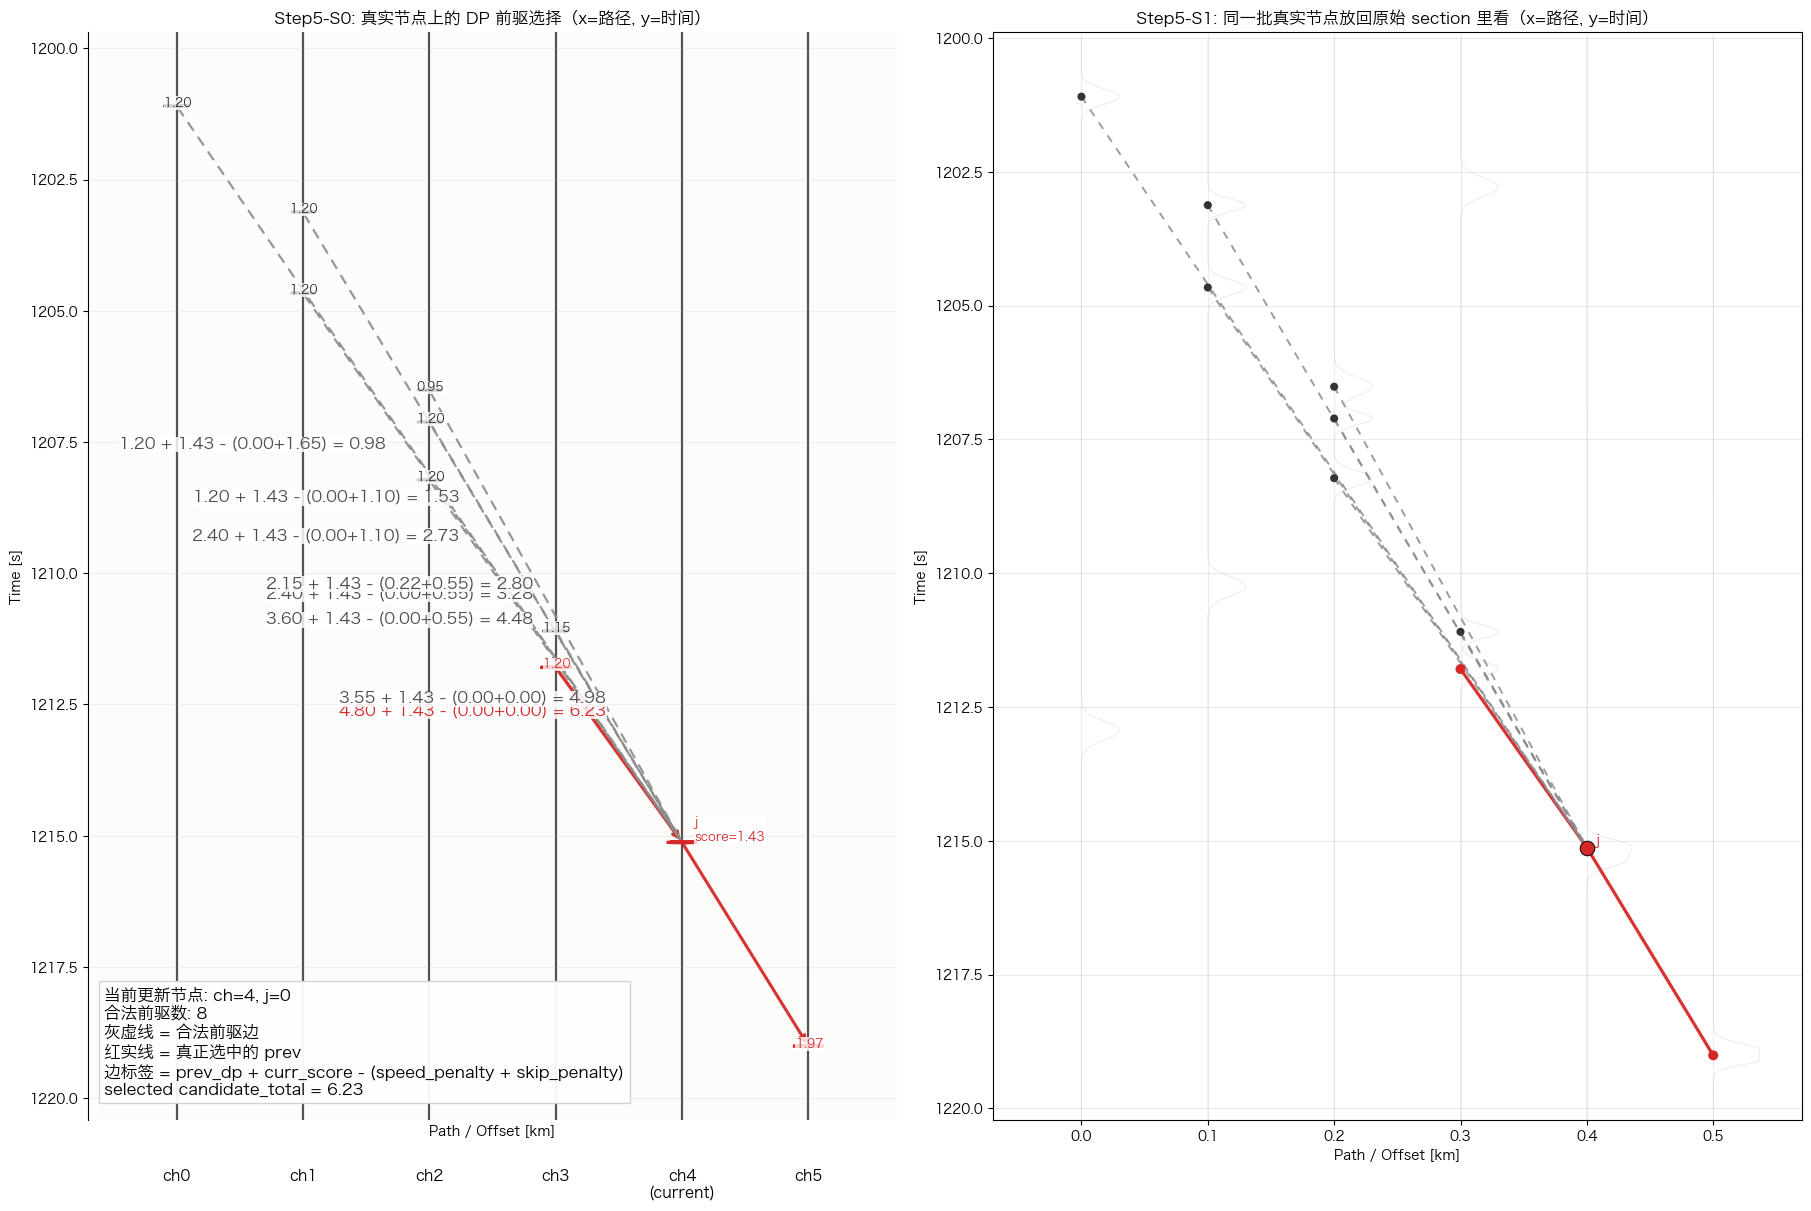

In [12]:
if best_track is not None and dp_debug["best_end"] is not None:
    from matplotlib.patches import Circle, FancyArrowPatch

    def _find_focus_transition():
        path = dp_debug["path"]
        best_focus = None
        best_records = []
        for pos in range(1, len(path)):
            ch, idx = path[pos]
            records = inspect_transition(
                nodes_dp, dp_debug, ch, idx, fs, dx_m, DIRECTION, vmin_mps, vmax_mps, CFG
            )
            if len(records) > len(best_records):
                best_focus = (pos, ch, idx)
                best_records = records
        return best_focus, best_records

    def _edge_formula(rec, curr_score):
        return (
            f"{rec['prev_total']:.2f} + {curr_score:.2f} - "
            f"({rec['speed_penalty']:.2f}+{rec['skip_penalty']:.2f}) = {rec['candidate_total']:.2f}"
        )

    def _draw_tick_node(ax, x, y, color, label=None, circle=False, label_dx=-0.010, label_dy=0.10, lw=2.6):
        ax.plot([x - 0.009, x + 0.009], [y, y], color=color, lw=lw, solid_capstyle="round", zorder=4)
        if circle:
            ax.add_patch(Circle((x, y), 0.012, facecolor="none", edgecolor=color, lw=2.0, zorder=5))
        if label is not None:
            ax.text(
                x + label_dx,
                y + label_dy,
                label,
                color=color,
                fontsize=9,
                ha="left",
                va="bottom",
                zorder=6,
                bbox={"facecolor": "white", "alpha": 0.80, "edgecolor": "none", "pad": 0.25},
            )

    focus, focus_records = _find_focus_transition()
    if focus is None or len(focus_records) == 0:
        print("没有找到适合展示的真实当前节点。")
    else:
        focus_step, focus_ch, focus_idx = focus
        path = dp_debug["path"]
        current_t = float(nodes_dp[focus_ch]["t"][focus_idx]) / fs + window_t0
        curr_score = float(nodes_dp[focus_ch]["score"][focus_idx])
        current_x = float(offsets_m[focus_ch]) * 1e-3
        selected_rec = next((rec for rec in focus_records if rec["is_selected"]), None)
        next_pt = path[focus_step + 1] if focus_step + 1 < len(path) else None

        records_to_draw = focus_records
        channels = {focus_ch, *(rec["pch"] for rec in records_to_draw)}
        if next_pt is not None:
            channels.add(next_pt[0])
        channels = sorted(channels)
        x_map = {ch: float(offsets_m[ch]) * 1e-3 for ch in channels}
        x_vals = [x_map[ch] for ch in channels]
        x_pad = 0.08 if len(x_vals) < 2 else 0.7 * float(np.median(np.diff(x_vals)))

        prev_times = [float(rec["prev_t_idx"]) / fs + window_t0 for rec in records_to_draw]
        all_times = prev_times + [current_t]
        if next_pt is not None:
            next_t = float(nodes_dp[next_pt[0]]["t"][next_pt[1]]) / fs + window_t0
            all_times.append(next_t)
        else:
            next_t = None
        t_min = min(all_times) - 1.4
        t_max = max(all_times) + 1.4

        fig, axes = plt.subplots(1, 2, figsize=(18, 12), constrained_layout=True)
        ax0, ax1 = axes

        ax0.set_facecolor("#fcfcfb")
        for ch in channels:
            x = x_map[ch]
            ax0.axvline(x, color="0.25", lw=1.6, alpha=0.9, zorder=1)
            ax0.text(
                x,
                -0.045,
                f"ch{ch}" + ("\n(current)" if ch == focus_ch else ""),
                transform=ax0.get_xaxis_transform(),
                ha="center",
                va="top",
                fontsize=11,
            )

        selected_color = "tab:red"
        valid_color = "0.55"

        for k, rec in enumerate(records_to_draw):
            prev_ch = rec["pch"]
            prev_idx = rec["prev_idx"]
            prev_t = float(rec["prev_t_idx"]) / fs + window_t0
            x0 = x_map[prev_ch]
            x1 = current_x
            y0 = prev_t
            y1 = current_t
            chosen = rec["is_selected"]

            prev_local_score = float(nodes_dp[prev_ch]["score"][prev_idx])
            _draw_tick_node(
                ax0,
                x0,
                y0,
                selected_color if chosen else "0.15",
                label=f"{prev_local_score:.2f}",
                circle=chosen,
                label_dx=-0.010,
                label_dy=0.07,
            )

            edge = FancyArrowPatch(
                (x0, y0),
                (x1, y1),
                arrowstyle="->" if chosen else "-",
                mutation_scale=10,
                lw=2.4 if chosen else 1.6,
                linestyle="-" if chosen else (0, (4, 4)),
                color=selected_color if chosen else valid_color,
                alpha=0.95 if chosen else 0.9,
                zorder=2,
            )
            ax0.add_patch(edge)

            mid_x = 0.58 * x0 + 0.42 * x1
            spread = (k - (len(records_to_draw) - 1) / 2.0) * 0.16
            formula = _edge_formula(rec, curr_score)
            ax0.text(
                mid_x - 0.002,
                0.58 * y0 + 0.42 * y1 + spread,
                formula,
                fontsize=12,
                color=selected_color if chosen else "0.30",
                ha="right",
                va="center",
                zorder=6,
                bbox={"facecolor": "white", "alpha": 0.83, "edgecolor": "none", "pad": 0.20},
            )

        _draw_tick_node(
            ax0,
            current_x,
            current_t,
            selected_color,
            label=f"j\nscore={curr_score:.2f}",
            circle=True,
            label_dx=0.010,
            label_dy=0.02,
            lw=2.8,
        )

        if next_pt is not None and next_t is not None:
            next_score = float(nodes_dp[next_pt[0]]["score"][next_pt[1]])
            next_x = float(offsets_m[next_pt[0]]) * 1e-3
            _draw_tick_node(
                ax0,
                next_x,
                next_t,
                selected_color,
                label=f"{next_score:.2f}",
                circle=True,
                label_dx=-0.010,
                label_dy=0.08,
            )
            ax0.add_patch(
                FancyArrowPatch(
                    (current_x, current_t),
                    (next_x, next_t),
                    arrowstyle="->",
                    mutation_scale=10,
                    lw=2.2,
                    linestyle="-",
                    color=selected_color,
                    alpha=0.95,
                    zorder=3,
                )
            )

        info_lines = [
            f"当前更新节点: ch={focus_ch}, j={focus_idx}",
            f"合法前驱数: {len(records_to_draw)}",
            "灰虚线 = 合法前驱边",
            "红实线 = 真正选中的 prev",
            "边标签 = prev_dp + curr_score - (speed_penalty + skip_penalty)",
        ]
        if selected_rec is not None:
            info_lines.append(f"selected candidate_total = {selected_rec['candidate_total']:.2f}")
        ax0.text(
            0.02,
            0.02,
            "\n".join(info_lines),
            transform=ax0.transAxes,
            ha="left",
            va="bottom",
            fontsize=12,
            bbox={"facecolor": "white", "alpha": 0.95, "edgecolor": "0.82"},
        )
        ax0.set_title("Step5-S0: 真实节点上的 DP 前驱选择（x=路径, y=时间）")
        ax0.set_xlabel("Path / Offset [km]")
        ax0.set_ylabel("Time [s]")
        ax0.set_xlim(min(x_vals) - x_pad, max(x_vals) + x_pad)
        ax0.set_ylim(t_max, t_min)
        ax0.set_xticks([])
        ax0.grid(axis="y", alpha=0.18)
        for spine in ["top", "right", "bottom"]:
            ax0.spines[spine].set_visible(False)

        plot_section_wiggle(ax1, data, t_abs, offsets_m, color="0.84", alpha=0.45)
        x_curr = current_x
        y_curr = current_t
        ax1.scatter([x_curr], [y_curr], s=110, color=selected_color, edgecolors="k", linewidths=0.7, zorder=6)
        ax1.text(x_curr, y_curr, "  j", color=selected_color, fontsize=10, ha="left", va="bottom")

        for rec in records_to_draw:
            prev_ch = rec["pch"]
            prev_t = float(rec["prev_t_idx"]) / fs + window_t0
            prev_x = float(offsets_m[prev_ch]) * 1e-3
            ax1.plot(
                [prev_x, x_curr],
                [prev_t, y_curr],
                color=selected_color if rec["is_selected"] else valid_color,
                lw=2.3 if rec["is_selected"] else 1.4,
                ls="-" if rec["is_selected"] else (0, (4, 4)),
                alpha=0.95 if rec["is_selected"] else 0.85,
                zorder=4,
            )
            ax1.scatter(
                [prev_x],
                [prev_t],
                s=52 if rec["is_selected"] else 34,
                color=selected_color if rec["is_selected"] else "0.20",
                edgecolors="none",
                zorder=5,
            )

        if next_pt is not None and next_t is not None:
            next_x = float(offsets_m[next_pt[0]]) * 1e-3
            ax1.plot([x_curr, next_x], [y_curr, next_t], color=selected_color, lw=2.3, alpha=0.95, zorder=4)
            ax1.scatter([next_x], [next_t], s=52, color=selected_color, edgecolors="none", zorder=5)

        t_lo = min(all_times) - 1.2
        t_hi = max(all_times) + 1.2
        ax1.set_xlim(min(x_vals) - x_pad, max(x_vals) + x_pad)
        ax1.set_ylim(t_hi, t_lo)
        ax1.set_title("Step5-S1: 同一批真实节点放回原始 section 里看（x=路径, y=时间）")

        plt.show()


这一组图不再用玩具草图，而是直接从**当前窗口的真实候选峰**里挑一个正在更新的节点 `j` 来展示。

- 左图：把真实候选点按 `channel` 排开，只画出这个 `j` 的所有合法前驱
- 灰虚线：时间差落在速度窗里，所以**允许连边**
- 红实线：DP 最后真的选中的 `prev`
- 每条边旁边都直接写：
  `prev_dp + curr_score - (speed_penalty + skip_penalty) = candidate_total`
- 右图：把同一批真实节点放回真实 `section` 里看，方便把“抽象连边图”和原始数据对应起来

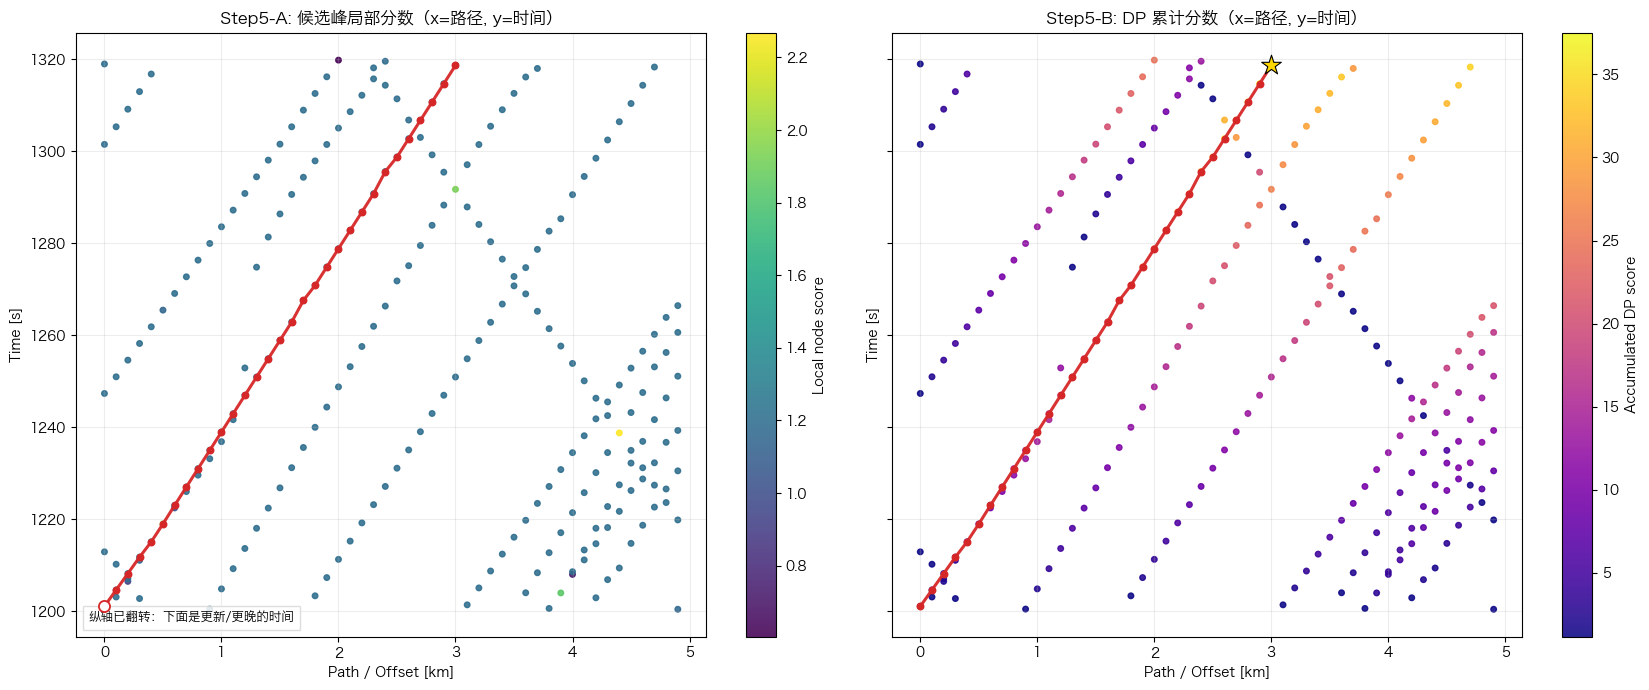

In [13]:
if best_track is not None and dp_debug["best_end"] is not None:
    all_x_path = []
    all_y_time = []
    all_local_score = []
    all_dp_score = []
    for ch, nd in enumerate(nodes_dp):
        if nd["t"].size == 0:
            continue
        all_x_path.append(np.full(nd["t"].shape, offsets_m[ch] * 1e-3, dtype=np.float64))
        all_y_time.append(nd["t"] / fs + window_t0)
        all_local_score.append(nd["score"].astype(np.float64))
        all_dp_score.append(dp_debug["dp_score"][ch].astype(np.float64))

    all_x_path = np.concatenate(all_x_path)
    all_y_time = np.concatenate(all_y_time)
    all_local_score = np.concatenate(all_local_score)
    all_dp_score = np.concatenate(all_dp_score)

    path = dp_debug["path"]
    path_x = np.array([offsets_m[ch] * 1e-3 for ch, idx in path], dtype=np.float64)
    path_y = np.array([nodes_dp[ch]["t"][idx] / fs + window_t0 for ch, idx in path], dtype=np.float64)

    end_ch, end_idx = dp_debug["best_end"]
    end_x = float(offsets_m[end_ch]) * 1e-3
    end_y = float(nodes_dp[end_ch]["t"][end_idx]) / fs + window_t0

    fig, axes = plt.subplots(1, 2, figsize=(17, 7), sharex=True, sharey=True)

    sc0 = axes[0].scatter(all_x_path, all_y_time, c=all_local_score, s=16, cmap="viridis", alpha=0.88)
    axes[0].plot(path_x, path_y, color="tab:red", lw=2.2, alpha=0.95)
    axes[0].scatter(path_x, path_y, color="tab:red", s=22, zorder=4)
    axes[0].scatter([path_x[0]], [path_y[0]], s=64, color="white", edgecolors="tab:red", linewidths=1.3, zorder=5)
    axes[0].set_title("Step5-A: 候选峰局部分数（x=路径, y=时间）")
    fig.colorbar(sc0, ax=axes[0], label="Local node score")

    sc1 = axes[1].scatter(all_x_path, all_y_time, c=all_dp_score, s=16, cmap="plasma", alpha=0.88)
    axes[1].plot(path_x, path_y, color="tab:red", lw=2.2, alpha=0.95)
    axes[1].scatter(path_x, path_y, color="tab:red", s=22, zorder=4)
    axes[1].scatter([end_x], [end_y], marker="*", s=220, color="gold", edgecolors="k", linewidths=0.8, zorder=5)
    axes[1].set_title("Step5-B: DP 累计分数（x=路径, y=时间）")
    fig.colorbar(sc1, ax=axes[1], label="Accumulated DP score")

    for ax in axes:
        ax.set_xlabel("Path / Offset [km]")
        ax.set_ylabel("Time [s]")
        ax.grid(alpha=0.22)
        ax.invert_yaxis()

    axes[0].text(
        0.02,
        0.02,
        "纵轴已翻转：下面是更新/更晚的时间",
        transform=axes[0].transAxes,
        ha="left",
        va="bottom",
        fontsize=9,
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "0.85"},
    )

    plt.tight_layout()
    plt.show()


### 5.4 看一个“中间节点”是怎么选前驱的

上面那张图回答的是“最后哪条轨迹赢了”。

下面我们把视角缩小到 **最佳轨迹中间的一个节点**，看看它在更新 `dp_score` 时，到底比较了哪些候选前驱，为什么最后只保留了其中一个。重点看 4 个量：

- `prev_total`：前驱节点那条路径之前已经攒下来的分数
- `curr_score`：当前节点自己的分数
- `speed_penalty`：速度和已有轨迹不一致时扣掉多少
- `skip_penalty`：跨通道跳连时扣掉多少

最终比较的是：

```python
candidate_total = prev_total + curr_score - speed_penalty - skip_penalty
```

右边柱状图里，柱子越高，说明“把那个前驱接到当前节点上”越划算。红色柱就是最终被选中的前驱。


focus step=4, channel=4, local_idx=0, valid predecessors=8
Top predecessor candidates: [pch, prev_idx, dt(s), speed(km/h), prev_total, speed_pen, skip_pen, candidate_total]
  ch003/idx002, dt= 3.336, v= 107.91, prev=  4.800, spd_pen=0.000, skip_pen=0.000, cand=  6.227 <-- selected
  ch003/idx001, dt= 4.032, v=  89.29, prev=  3.550, spd_pen=0.000, skip_pen=0.000, cand=  4.977 
  ch002/idx002, dt= 6.902, v= 104.32, prev=  3.600, spd_pen=0.000, skip_pen=0.550, cand=  4.477 
  ch002/idx001, dt= 8.018, v=  89.80, prev=  2.404, spd_pen=0.000, skip_pen=0.550, cand=  3.281 
  ch002/idx000, dt= 8.612, v=  83.60, prev=  2.147, spd_pen=0.222, skip_pen=0.550, cand=  2.802 
  ch001/idx001, dt=10.466, v= 103.19, prev=  2.400, spd_pen=0.000, skip_pen=1.100, cand=  2.727 
  ch001/idx000, dt=12.004, v=  89.97, prev=  1.200, spd_pen=0.000, skip_pen=1.100, cand=  1.527 
  ch000/idx000, dt=14.032, v= 102.62, prev=  1.200, spd_pen=0.000, skip_pen=1.650, cand=  0.978 


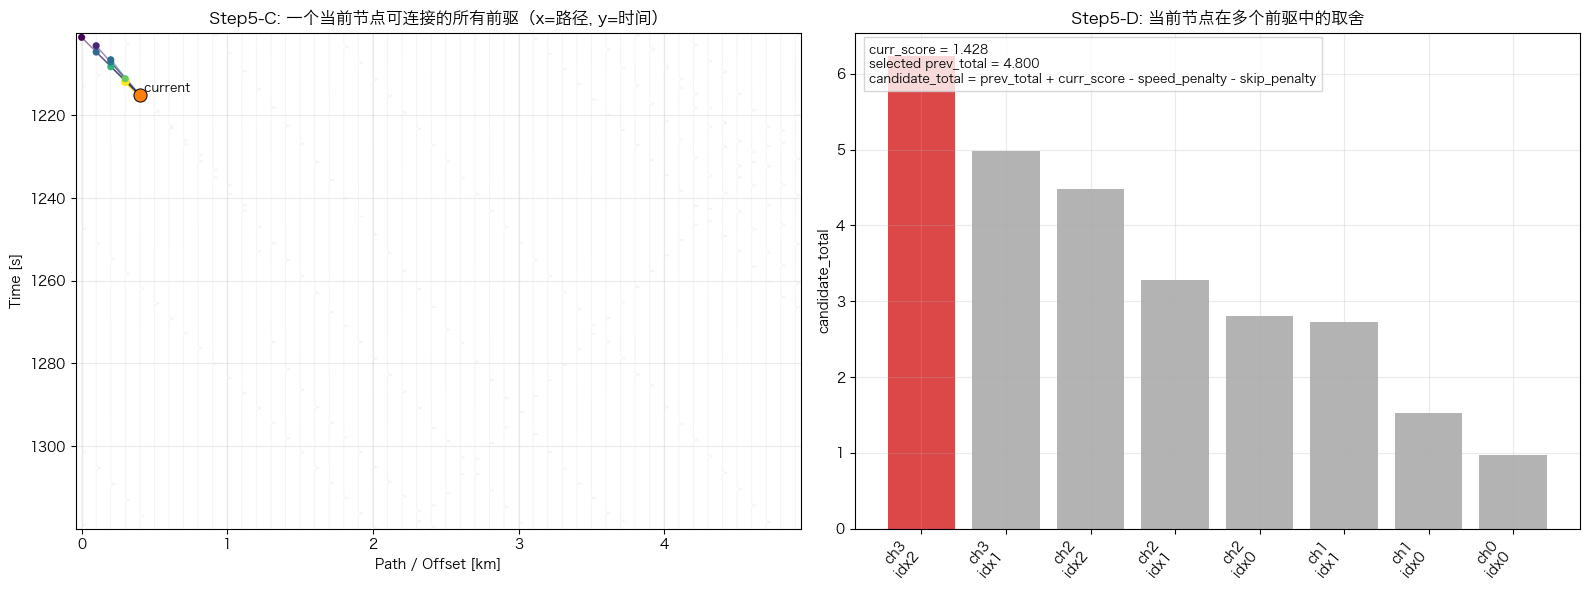

In [14]:
if best_track is not None and dp_debug["best_end"] is not None:
    path = dp_debug["path"]
    best_focus = None
    best_records = []
    for pos in range(1, len(path)):
        ch, idx = path[pos]
        records = inspect_transition(
            nodes_dp, dp_debug, ch, idx, fs, dx_m, DIRECTION, vmin_mps, vmax_mps, CFG
        )
        if len(records) > len(best_records):
            best_focus = (pos, ch, idx)
            best_records = records

    if best_focus is None:
        print("轨迹只有 1 个点，无法展示前驱选择。")
    else:
        pos, focus_ch, focus_idx = best_focus
        focus_records = best_records
        curr_t_abs = float(nodes_dp[focus_ch]["t"][focus_idx]) / fs + window_t0
        curr_x = float(offsets_m[focus_ch]) * 1e-3

        top_k = min(12, len(focus_records))
        top_records = focus_records[:top_k]

        print(f"focus step={pos}, channel={focus_ch}, local_idx={focus_idx}, valid predecessors={len(focus_records)}")
        print("Top predecessor candidates: [pch, prev_idx, dt(s), speed(km/h), prev_total, speed_pen, skip_pen, candidate_total]")
        for rec in top_records:
            flag = "<-- selected" if rec["is_selected"] else ""
            print(
                f"  ch{rec['pch']:03d}/idx{rec['prev_idx']:03d}, dt={rec['dt_s']:6.3f}, "
                f"v={rec['speed_kmh']:7.2f}, prev={rec['prev_total']:7.3f}, "
                f"spd_pen={rec['speed_penalty']:5.3f}, skip_pen={rec['skip_penalty']:5.3f}, "
                f"cand={rec['candidate_total']:7.3f} {flag}"
            )

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        plot_section_wiggle(axes[0], data, t_abs, offsets_m, color="0.88", alpha=0.35)
        axes[0].scatter([curr_x], [curr_t_abs], s=90, color="tab:orange", edgecolors="k", linewidths=0.7, zorder=5)
        axes[0].text(curr_x, curr_t_abs, " current", fontsize=9, ha="left", va="bottom")

        cand_vals = np.array([rec["candidate_total"] for rec in top_records], dtype=np.float64)
        vmin = float(np.min(cand_vals)) if cand_vals.size else 0.0
        vmax = float(np.max(cand_vals)) if cand_vals.size else 1.0
        denom = max(1e-9, vmax - vmin)

        for rec in top_records:
            prev_t_abs = float(rec["prev_t_idx"]) / fs + window_t0
            prev_x = float(offsets_m[rec["pch"]]) * 1e-3
            ratio = (rec["candidate_total"] - vmin) / denom
            color = plt.cm.viridis(ratio)
            lw = 2.4 if rec["is_selected"] else 1.0
            alpha = 0.95 if rec["is_selected"] else 0.55
            axes[0].plot([prev_x, curr_x], [prev_t_abs, curr_t_abs], color=color, lw=lw, alpha=alpha)
            axes[0].scatter([prev_x], [prev_t_abs], s=42 if rec["is_selected"] else 26, color=[color], edgecolors="none", zorder=4)

        axes[0].set_title("Step5-C: 一个当前节点可连接的所有前驱（x=路径, y=时间）")

        labels = [f"ch{rec['pch']}\nidx{rec['prev_idx']}" for rec in top_records]
        bar_colors = ["tab:red" if rec["is_selected"] else "0.65" for rec in top_records]
        axes[1].bar(np.arange(top_k), [rec["candidate_total"] for rec in top_records], color=bar_colors, alpha=0.85)
        axes[1].set_xticks(np.arange(top_k))
        axes[1].set_xticklabels(labels, rotation=50, ha="right")
        axes[1].set_ylabel("candidate_total")
        axes[1].set_title("Step5-D: 当前节点在多个前驱中的取舍")

        selected_rec = next((rec for rec in focus_records if rec["is_selected"]), None)
        formula_lines = [
            f"curr_score = {float(nodes_dp[focus_ch]['score'][focus_idx]):.3f}",
            f"selected prev_total = {selected_rec['prev_total']:.3f}" if selected_rec is not None else "selected bar marked in red",
            "candidate_total = prev_total + curr_score - speed_penalty - skip_penalty",
        ]
        axes[1].text(
            0.02,
            0.98,
            "\n".join(formula_lines),
            transform=axes[1].transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "0.8"},
        )

        plt.tight_layout()
        plt.show()


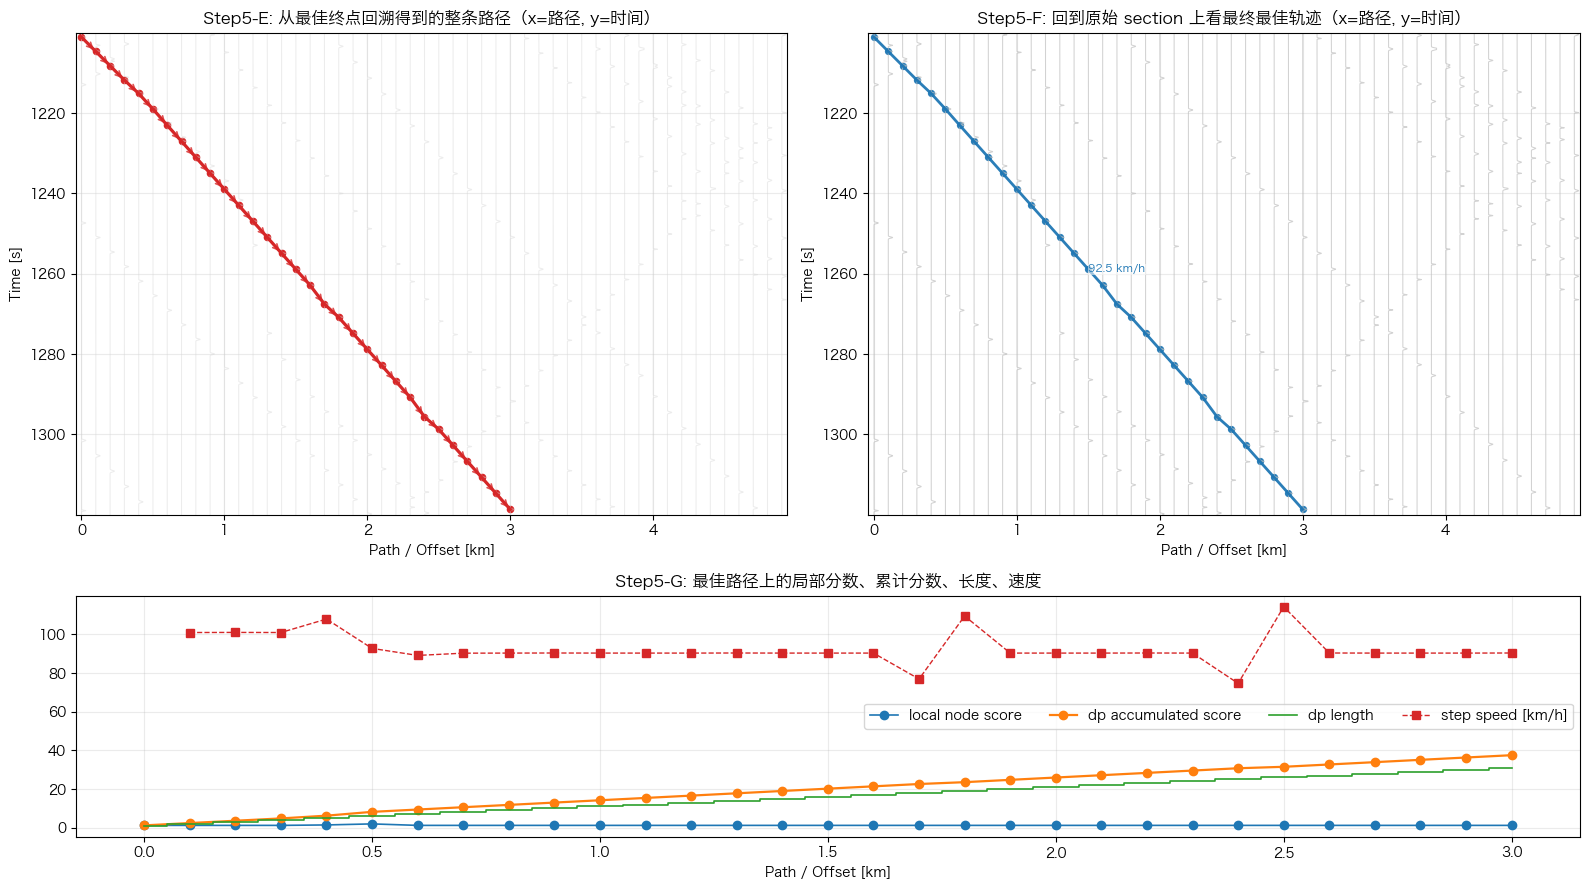

In [15]:
if best_track is not None and dp_debug["best_end"] is not None:
    path = dp_debug["path"]
    path_time = np.array([nodes_dp[ch]["t"][idx] / fs + window_t0 for ch, idx in path], dtype=np.float64)
    path_x = np.array([offsets_m[ch] * 1e-3 for ch, idx in path], dtype=np.float64)
    path_local = np.array([nodes_dp[ch]["score"][idx] for ch, idx in path], dtype=np.float64)
    path_total = np.array([dp_debug["dp_score"][ch][idx] for ch, idx in path], dtype=np.float64)
    path_len = np.array([dp_debug["dp_len"][ch][idx] for ch, idx in path], dtype=np.int32)

    step_speed_kmh = np.full(path_time.shape, np.nan, dtype=np.float64)
    if path_time.size >= 2:
        dt = np.diff(path_time)
        dch = np.diff([ch for ch, _ in path]).astype(np.float64)
        valid = np.abs(dt) > 1e-9
        step_speed_kmh[1:][valid] = 3.6 * np.abs(dch[valid]) * dx_m / np.abs(dt[valid])

    fig = plt.figure(figsize=(16, 9))
    gs = fig.add_gridspec(2, 2, height_ratios=[2.0, 1.0])
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1])
    ax2 = fig.add_subplot(gs[1, :])

    plot_section_wiggle(ax0, data, t_abs, offsets_m, color="0.84", alpha=0.45)
    ax0.plot(path_x, path_time, color="tab:red", lw=2.3)
    ax0.scatter(path_x, path_time, color="tab:red", s=20)
    for k in range(1, len(path_x)):
        ax0.annotate(
            "",
            xy=(path_x[k], path_time[k]),
            xytext=(path_x[k - 1], path_time[k - 1]),
            arrowprops={"arrowstyle": "->", "color": "tab:red", "lw": 1.2, "alpha": 0.8},
        )
    ax0.set_title("Step5-E: 从最佳终点回溯得到的整条路径（x=路径, y=时间）")

    plot_section_wiggle(ax1, data, t_abs, offsets_m, color="0.75", alpha=0.7)
    overlay_tracks(ax1, [best_track], time_offset_s=window_t0, cmap_name="tab10", lw=2.0, s=18)
    ax1.set_title("Step5-F: 回到原始 section 上看最终最佳轨迹（x=路径, y=时间）")

    ax2.plot(path_x, path_local, marker="o", lw=1.2, label="local node score")
    ax2.plot(path_x, path_total, marker="o", lw=1.6, label="dp accumulated score")
    ax2.step(path_x, path_len, where="mid", lw=1.2, label="dp length")
    if np.any(np.isfinite(step_speed_kmh)):
        ax2.plot(path_x, step_speed_kmh, marker="s", lw=1.0, ls="--", label="step speed [km/h]")
    ax2.set_title("Step5-G: 最佳路径上的局部分数、累计分数、长度、速度")
    ax2.set_xlabel("Path / Offset [km]")
    ax2.legend(loc="best", ncol=4)

    plt.tight_layout()
    plt.show()


## 6) 多轨迹迭代提取（NMS）

iterative tracks: 11
top-10 speeds (km/h):
  track 00: points= 31, speed=  92.48, score=   37.50
  track 01: points= 29, speed=  90.81, score=   34.25
  track 02: points= 28, speed=  85.10, score=   33.35
  track 03: points= 21, speed=  99.37, score=   24.55
  track 04: points= 18, speed=  97.93, score=   21.60
  track 05: points= 14, speed=  83.77, score=   17.09
  track 06: points= 12, speed=  79.15, score=   14.39
  track 07: points= 11, speed=  95.28, score=   12.96
  track 08: points=  9, speed=  93.82, score=    9.25
  track 09: points=  7, speed=  91.31, score=    7.85


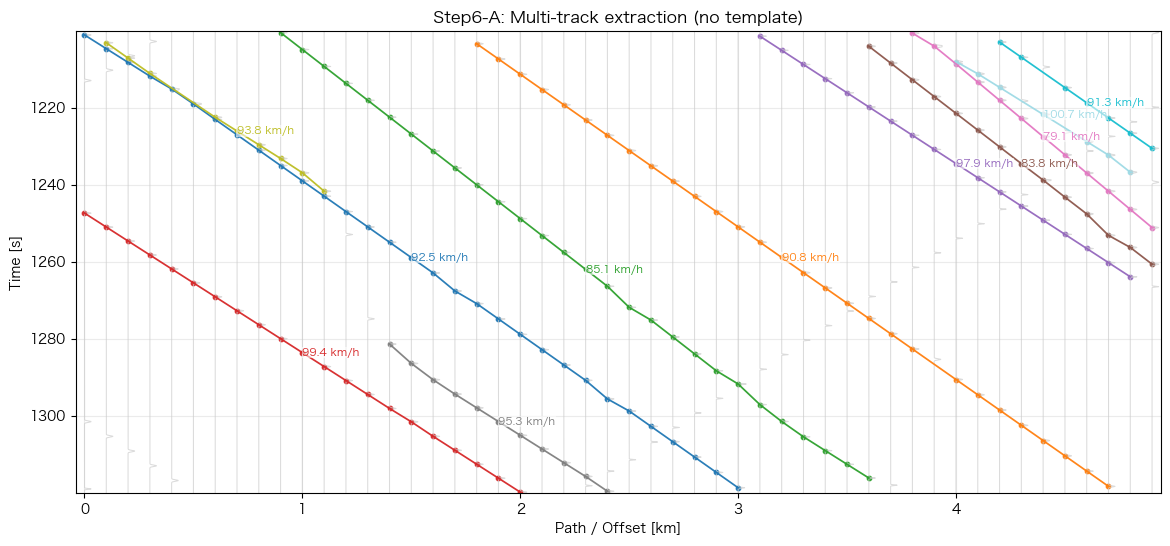

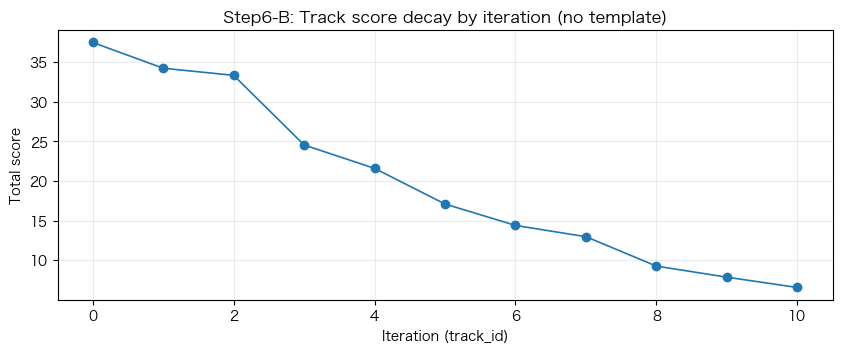

In [16]:
nodes_iter = [
    {"t": n["t"].copy(), "amp": n["amp"].copy(), "score": n["score"].copy()}
    for n in nodes_no_tmpl
]

tracks_iter = []
for tid in range(MAX_TRACKS_DEMO):
    tr = _extract_best_track(
        nodes=nodes_iter,
        fs=fs,
        dx_m=dx_m,
        direction=DIRECTION,
        vmin_mps=vmin_mps,
        vmax_mps=vmax_mps,
        n_samples=data.shape[1],
        config=CFG,
        track_id=tid,
    )
    if tr is None:
        break
    tracks_iter.append(tr)
    _suppress_nodes(nodes_iter, tr, CFG)

print("iterative tracks:", len(tracks_iter))
if tracks_iter:
    print("top-10 speeds (km/h):")
    for tr in tracks_iter[:10]:
        print(f"  track {tr.track_id:02d}: points={len(tr.points):3d}, speed={float(tr.mean_speed_kmh):7.2f}, score={float(tr.total_score):8.2f}")

fig, ax = plt.subplots(figsize=(14, 6))
plot_section_wiggle(ax, data, t_abs, offsets_m, color="0.8", alpha=0.7)
overlay_tracks(ax, tracks_iter, time_offset_s=window_t0, cmap_name="tab20", lw=1.25, s=10)
ax.set_title("Step6-A: Multi-track extraction (no template)")
plt.show()

if tracks_iter:
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot([float(t.total_score) for t in tracks_iter], marker="o", lw=1.2)
    ax.set_title("Step6-B: Track score decay by iteration (no template)")
    ax.set_xlabel("Iteration (track_id)")
    ax.set_ylabel("Total score")
    plt.show()


## 7) 后处理（dedup + stitch）

after dedup+stitch tracks: 11


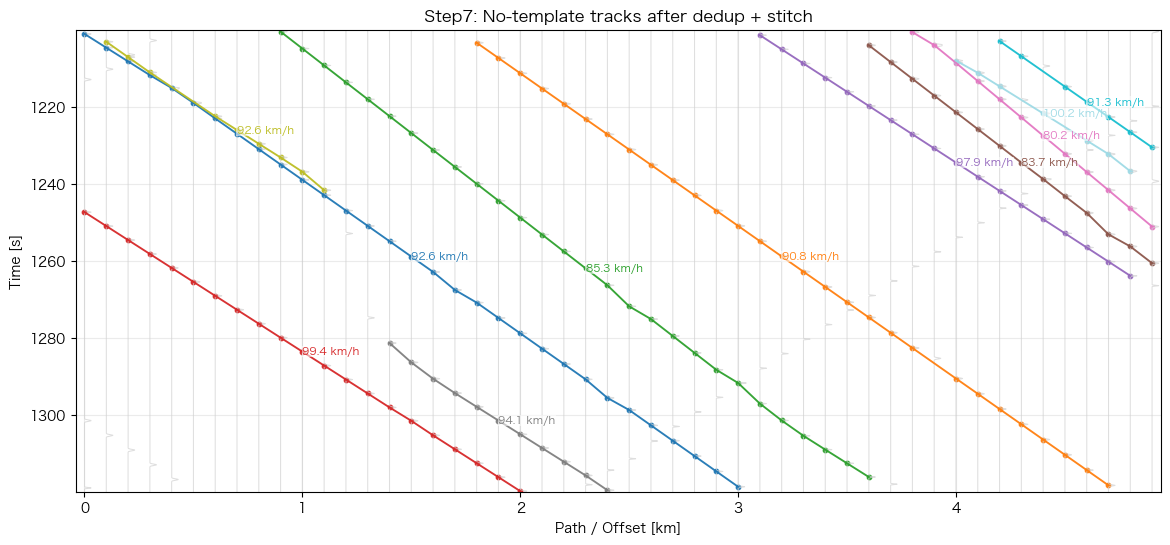

In [17]:
tracks_global = [backend._to_global_track(tr, backend.current_start) for tr in tracks_iter]
nms_samples = int(max(1, CFG.nms_time_radius))

dedup = backend._deduplicate_tracks(tracks_global, tol_samples=nms_samples)
stitched = backend._stitch_track_fragments(
    dedup,
    direction=DIRECTION,
    speed_min_kmh=SPEED_MIN_KMH,
    speed_max_kmh=SPEED_MAX_KMH,
    tol_samples=nms_samples,
)
stitched = backend._deduplicate_tracks(stitched, tol_samples=nms_samples)
stitched = sorted(stitched, key=lambda tr: tr.total_score, reverse=True)

print("after dedup+stitch tracks:", len(stitched))

fig, ax = plt.subplots(figsize=(14, 6))
plot_section_wiggle(ax, data, t_abs, offsets_m, color="0.82", alpha=0.7)
overlay_tracks(ax, stitched, time_offset_s=0.0, cmap_name="tab20", lw=1.35, s=10)
ax.set_title("Step7: No-template tracks after dedup + stitch")
plt.show()


## 8) 与模板增强版对比

template summary: {'track_count': 11, 'total_points': 184, 'avg_points_per_track': 16.727272727272727, 'elapsed_seconds': 1.1937850840040483, 'params': {'direction': 'forward', 'scope': 'current_window', 'engine': 'cpu_parallel', 'engine_text': 'CPU Parallel(10 workers)', 'parallel_workers': 10, 'gpu_device_id': None, 'speed_min_kmh': 60.0, 'speed_max_kmh': 120.0, 'prominence': 0.4, 'min_peak_distance': 500, 'min_track_channels': 12, 'tile_seconds': 120.0, 'overlap_seconds': 20.0, 'nms_time_radius_seconds': 0.18000001098632878, 'window_start_sample': 1200000, 'window_end_sample': 1320000, 'extractor_config': {'sigma_seconds': [0.06, 0.1, 0.14, 0.18], 'use_template_enhancement': True, 'enhance_decimate': 2, 'max_skip_channels': 4, 'lambda_speed': 2.0, 'lambda_skip': 0.55, 'speed_change_tolerance_kmh': 18.0, 'speed_penalty_power': 0.85, 'speed_penalty_cap': 2.5, 'min_track_score': 10.0, 'nms_channel_radius': 1}, 'stitch_config': {'max_gap_channels': 8, 'dt_slack_ratio': 0.35, 'max_speed_

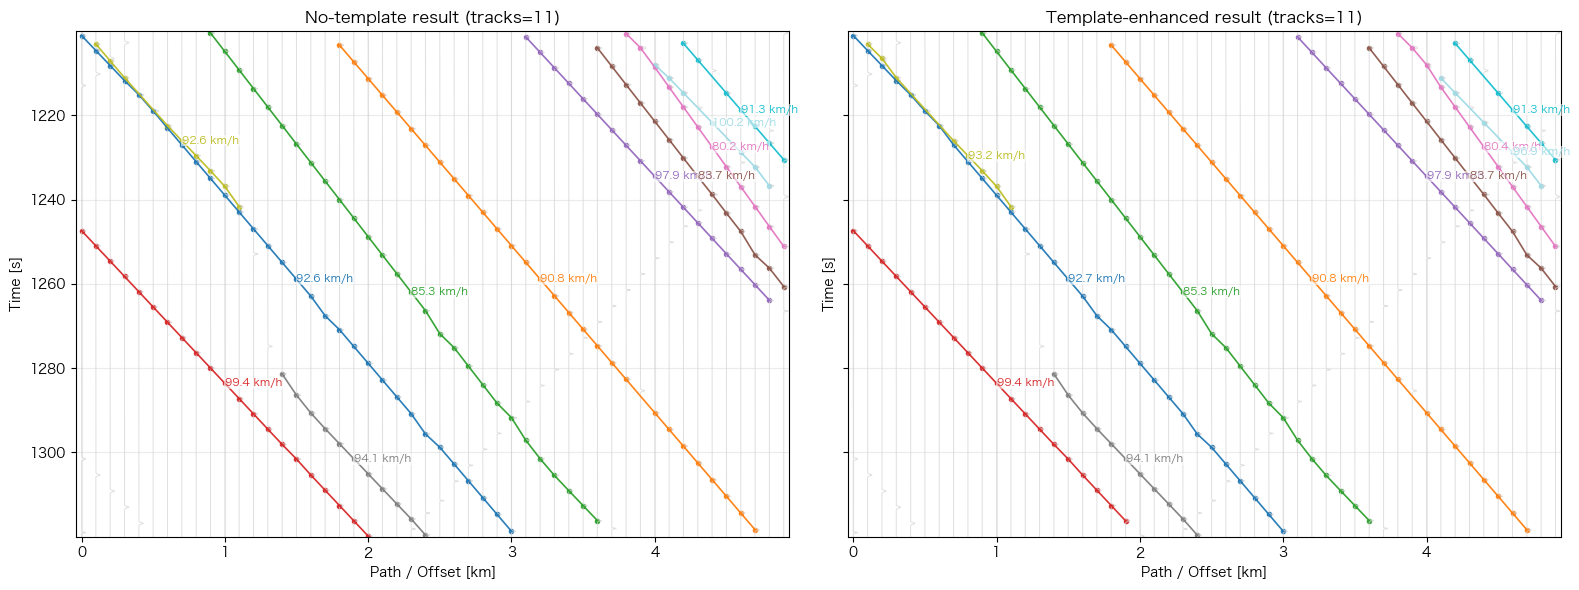

In [18]:
summary_template = backend.run_auto_extract(
    engine="cpu_parallel",
    direction=DIRECTION,
    speed_min_kmh=SPEED_MIN_KMH,
    speed_max_kmh=SPEED_MAX_KMH,
    prominence=CFG.prominence,
    min_peak_distance=CFG.min_peak_distance,
    min_track_channels=CFG.min_track_channels,
    tile_seconds=120,
    overlap_seconds=20,
    nms_time_radius=CFG.nms_time_radius / fs,
    current_window_only=True,
)
tracks_template = backend.tracks

print("template summary:", summary_template)
print("no-template track count:", len(stitched))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
plot_section_wiggle(axes[0], data, t_abs, offsets_m, color="0.83", alpha=0.7)
overlay_tracks(axes[0], stitched, time_offset_s=0.0, cmap_name="tab20", lw=1.2, s=9)
axes[0].set_title(f"No-template result (tracks={len(stitched)})")

plot_section_wiggle(axes[1], data, t_abs, offsets_m, color="0.83", alpha=0.7)
overlay_tracks(axes[1], tracks_template, time_offset_s=0.0, cmap_name="tab20", lw=1.2, s=9)
axes[1].set_title(f"Template-enhanced result (tracks={len(tracks_template)})")

plt.tight_layout()
plt.show()


## 说明

- 本 Notebook 完全跳过高斯模板增强，直接在 `|signal|` 上提峰。
- 你可以直接与模板增强版比较轨迹完整性和误检。

这 4 个参数里，前 1 个是“轨迹合法性门槛”，后 3 个主要是“整小时分块提取和去重控制”。

- `Min track channels`
  含义：一条轨迹至少要有多少个点，才算有效轨迹。代码里用的是 `dp_len >= min_track_channels`，见 [track_extractor_graph.py](/Volumes/SanDisk2T4/MyProjects/BaFang/KF/auto_track/track_extractor_graph.py:287)。
  直觉：太短的轨迹大概率是噪声碎片，不保留。
  调大：更严格，短轨迹、边缘轨迹更容易被删，误检少但漏检会增。
  调小：更宽松，能保留更短的真实轨迹，但碎片假轨迹会变多。
  补充：这里本质上是“最少路径点数”，通常接近“至少经过多少个通道点”；如果允许跳道，实际空间跨度可能比数字更大。窗口边界附近还会放宽到 `edge_min_track_channels=6`，见 [track_extractor_graph.py](/Volumes/SanDisk2T4/MyProjects/BaFang/KF/auto_track/track_extractor_graph.py:288)。

- `Tile seconds`
  含义：整小时模式下，每次切多长一个时间块来跑提取。见 [auto_track_backend.py](/Volumes/SanDisk2T4/MyProjects/BaFang/KF/auto_track/auto_track_backend.py:598)。
  直觉：不是整小时一次全跑，而是分块跑，降低计算量和内存压力。
  调大：每块更长，更稳、更不容易把轨迹切碎，但更慢、更占内存。
  调小：更快，但跨块边界更容易断轨。
  注意：这个参数在“Extract Current Window”时基本不起作用，主要用于 “Auto Extract (Full Hour)” 模式，见 [auto_track_backend.py](/Volumes/SanDisk2T4/MyProjects/BaFang/KF/auto_track/auto_track_backend.py:512)。

- `Overlap seconds`
  含义：相邻两个时间块之间重叠多少秒。见 [auto_track_backend.py](/Volumes/SanDisk2T4/MyProjects/BaFang/KF/auto_track/auto_track_backend.py:599)。
  直觉：防止车辆刚好落在分块边界时被切成两半。
  调大：跨块更稳，边界漏检更少，但重复轨迹更多，后处理压力更大。
  调小：速度更快，但边界更容易断轨。
  限制：必须小于 `tile_seconds`，GUI 里也做了检查，见 [auto_track_gui.py](/Volumes/SanDisk2T4/MyProjects/BaFang/KF/auto_track/auto_track_gui.py:442)。

- `NMS time radius (s)`
  含义：每提取出一条轨迹后，在这条轨迹附近的时间方向上“挖掉”多大的禁止带，避免同一辆车被重复提取。秒数会先换算成采样点，见 [auto_track_backend.py](/Volumes/SanDisk2T4/MyProjects/BaFang/KF/auto_track/auto_track_backend.py:519) 和 [track_extractor_graph.py](/Volumes/SanDisk2T4/MyProjects/BaFang/KF/auto_track/track_extractor_graph.py:350)。
  你的默认值 `0.18 s` 在 `1000 Hz` 下就是大约 `180` 个采样点。
  调大：重复轨迹更少，但时间很近的两辆车可能互相“压掉”，导致漏检。
  调小：相邻车辆更容易分开，但同一辆车的近似副本会变多。
  这个参数的经验解释在 [auto_track_algorithm.md](/Volumes/SanDisk2T4/MyProjects/BaFang/KF/auto_track/auto_track_algorithm.md:266) 也写了。

如果你愿意，我可以下一条直接按你这套数据给你一个实用调参建议，比如“车流密、重复多、漏检多”分别该先改哪一个。